# 2023 전력소비량 예측 모델

이 노트북은 전력소비량 예측을 위한 **탐색적 데이터 분석(EDA)**, **고도화된 전처리**, 그리고 **최신 부스팅 모델 앙상블** 과정을 통합하여 제공합니다.

## 통합 분석 및 모델링 단계
1. **데이터 로드 및 기본 확인**: 건물 정보 병합 및 구조 파악
2. **결측치 처리 (선형 보간)**: 기상 데이터의 연속성을 고려한 보간
3. **시간 변수 및 주기성 인코딩**: 요일/시간의 순환 구조 반영
4. **상세 EDA**: 건물 유형별 소비 패턴 및 '건물기타' 그룹 정밀 분석
5. **이상치 및 공휴 처리**: 임시 휴무 탐지 및 주요 공휴일 변수화
6. **냉방 지연 효과 반영**: 기온/불쾌지수의 **3시간 이동 평균** 피처 생성
7. **건물 세분화 군집화**: K-Means를 활용한 '기타' 건물군 세분화
8. **Weighted Ensemble**: Optuna로 튜닝된 **XGBoost + CatBoost** 가중 평균 모델링
9. **종합 평가**: SMAPE 지수 시각화 및 결론 도출

## 1. 데이터 로드
- 전력 소비 데이터와 기상 데이터를 불러오고 구조를 파악합니다.

In [2]:
# optuna 라이브러리 설치 (만약 설치되어 있지 않다면)
!pip install optuna
# catboost 라이브러리 설치 (만약 설치되어 있지 않다면)
!pip install catboost

# 한글 폰트 설정 (런타임 재시작 후 적용)
!sudo apt-get update -qq
!sudo apt-get install -y fonts-nanum > /dev/null
!sudo fc-cache -fv > /dev/null
!rm -rf ~/.cache/matplotlib # Matplotlib 캐시 삭제

import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

def smape(y_true, y_pred):
    return 100/len(y_true) * np.sum(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))

warnings.filterwarnings('ignore')

# 런타임 재시작 후 'NanumGothic' 사용
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

print("분석에 필요한 라이브러리를 로드했습니다.")

# 1. 데이터 로드
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
building_info = pd.read_csv('building_info.csv')

# 2. '건물번호'를 기준으로 건물 정보 병합
train = pd.merge(train, building_info, on='건물번호', how='left')
test = pd.merge(test, building_info, on='건물번호', how='left')
print("데이터 로드 완료")
print(f"Train 데이터 크기: {train.shape}")
print(f"Test 데이터 크기: {test.shape}")

'sudo'��(��) ���� �Ǵ� �ܺ� ����, ������ �� �ִ� ���α׷�, �Ǵ�
��ġ ������ �ƴմϴ�.
������ ��θ� ã�� �� �����ϴ�.
������ ��θ� ã�� �� �����ϴ�.


분석에 필요한 라이브러리를 로드했습니다.


'rm'��(��) ���� �Ǵ� �ܺ� ����, ������ �� �ִ� ���α׷�, �Ǵ�
��ġ ������ �ƴմϴ�.


데이터 로드 완료
Train 데이터 크기: (204000, 16)
Test 데이터 크기: (16800, 13)


In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204000 entries, 0 to 203999
Data columns (total 16 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   num_date_time  204000 non-null  object 
 1   건물번호           204000 non-null  int64  
 2   일시             204000 non-null  object 
 3   기온(C)          204000 non-null  float64
 4   강수량(mm)        43931 non-null   float64
 5   풍속(m/s)        203981 non-null  float64
 6   습도(%)          203991 non-null  float64
 7   일조(hr)         128818 non-null  float64
 8   일사(MJ/m2)      116087 non-null  float64
 9   전력소비량(kWh)     204000 non-null  float64
 10  건물유형           204000 non-null  object 
 11  연면적(m2)        204000 non-null  float64
 12  냉방면적(m2)       204000 non-null  float64
 13  태양광용량(kW)      204000 non-null  object 
 14  ESS저장용량(kWh)   204000 non-null  object 
 15  PCS용량(kW)      204000 non-null  object 
dtypes: float64(9), int64(1), object(6)
memory usage: 24.9+ MB


## 2. 결측치 확인 및 보간

- 강수량 등은 측정이 안 된 경우 0으로 처리합니다.
- 기온, 풍속, 습도는 선형 보간법(Linear Interpolation)을 사용합니다.

In [4]:
# '-' 형태의 결측치를 0으로 변환하고 float 타입으로 형변환
replace_cols = ['태양광용량(kW)', 'ESS저장용량(kWh)', 'PCS용량(kW)']
for col in replace_cols:
    train[col] = train[col].replace('-', 0).astype(float)
    test[col] = test[col].replace('-', 0).astype(float)

# 결측치 채우기
train['강수량(mm)'] = train['강수량(mm)'].fillna(0)
train['일조(hr)'] = train['일조(hr)'].fillna(0)
train['일사(MJ/m2)'] = train['일사(MJ/m2)'].fillna(0)
train[['기온(C)', '풍속(m/s)', '습도(%)']] = train[['기온(C)', '풍속(m/s)', '습도(%)']].interpolate(method='linear')

print("결측치 처리 완료")

결측치 처리 완료


## 3. 시간 변수 분리 및 주기성 시각화

일시 데이터를 기반으로 시간적 특징을 추출하고, 1주일 주기성을 원형 인코딩합니다.

In [5]:
train['일시'] = pd.to_datetime(train['일시'])
test['일시'] = pd.to_datetime(test['일시'])

for df in [train, test]:
    df['month'] = df['일시'].dt.month
    df['day'] = df['일시'].dt.day
    df['hour'] = df['일시'].dt.hour
    df['day_of_week'] = df['일시'].dt.weekday

    # 시간+요일 통합 주기성 인코딩
    df['total_hour_week'] = df['day_of_week'] * 24 + df['hour']
    df['sin_week_hour'] = np.sin(2 * np.pi * df['total_hour_week'] / 168)
    df['cos_week_hour'] = np.cos(2 * np.pi * df['total_hour_week'] / 168)

findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Fon

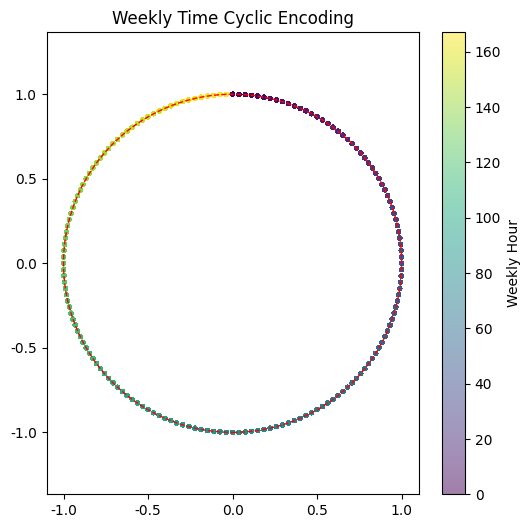

In [6]:
# 시간+요일 통합 주기성 시각화
plt.figure(figsize=(6, 6))
plt.scatter(train['sin_week_hour'], train['cos_week_hour'],
            c=train['total_hour_week'], cmap='viridis', s=5, alpha=0.5)
plt.colorbar(label='Weekly Hour')
circle = plt.Circle((0, 0), 1, color='red', fill=False, linestyle='--')
plt.gca().add_patch(circle)
plt.title('Weekly Time Cyclic Encoding')
plt.axis('equal')
plt.show()

## 4. 전력소비량 데이터 분석 (EDA)
타겟 변수의 분포와 유형별 패턴을 시각적으로 확인합니다.

findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Fon

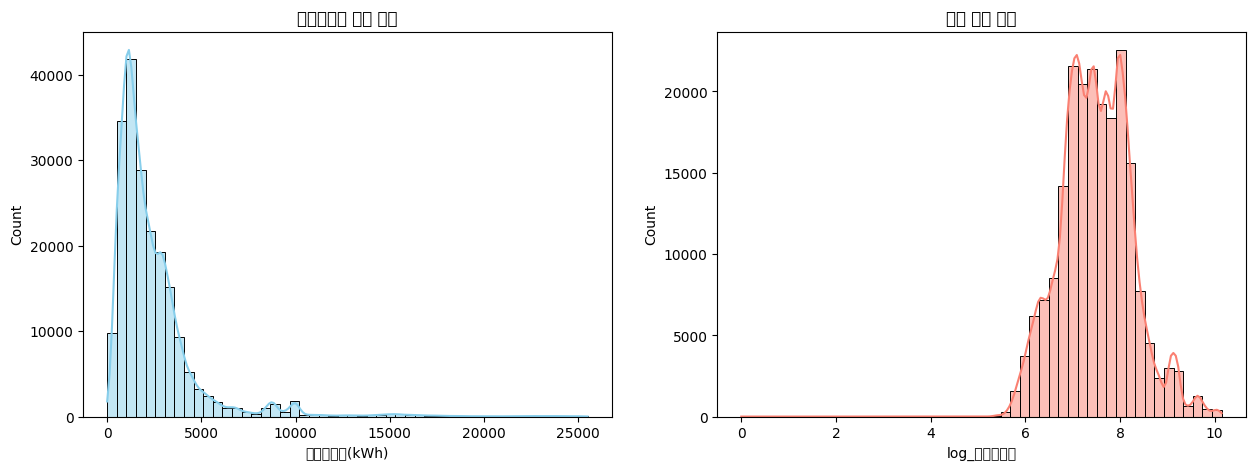

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(train['전력소비량(kWh)'], bins=50, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('전력소비량 원본 분포')

train['log_전력소비량'] = np.log1p(train['전력소비량(kWh)'])
sns.histplot(train['log_전력소비량'], bins=50, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('로그 변환 분포')
plt.show()

findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Fon

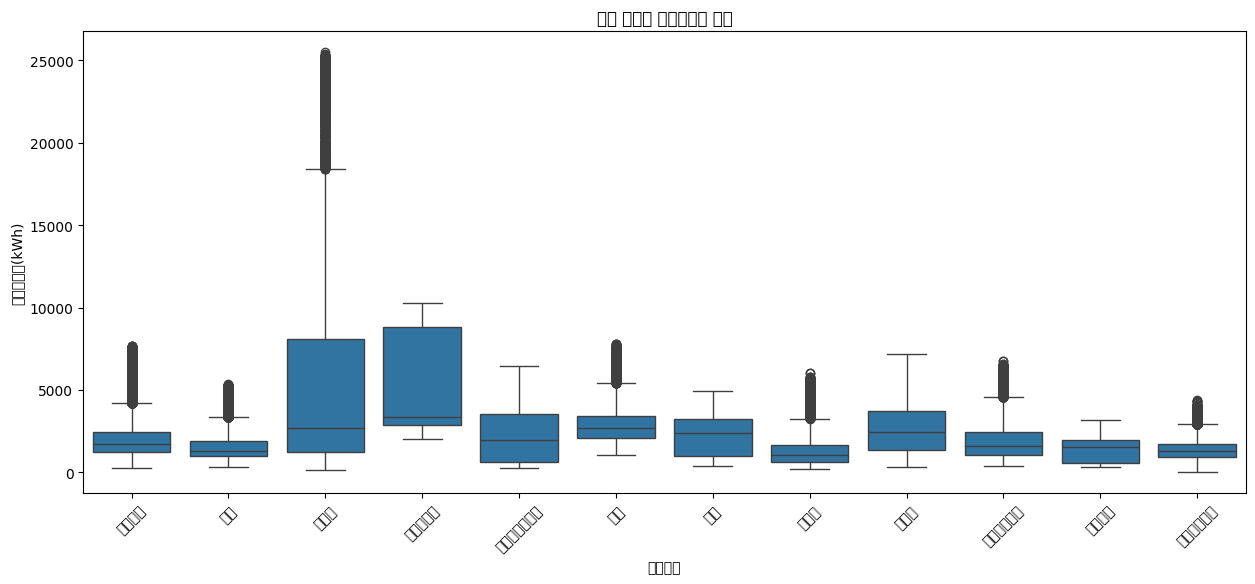

In [8]:
plt.figure(figsize=(15, 6))
sns.boxplot(data=train, x='건물유형', y='전력소비량(kWh)')
plt.xticks(rotation=45)
plt.title('건물 유형별 전력소비량 분포')
plt.show()

findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Fon

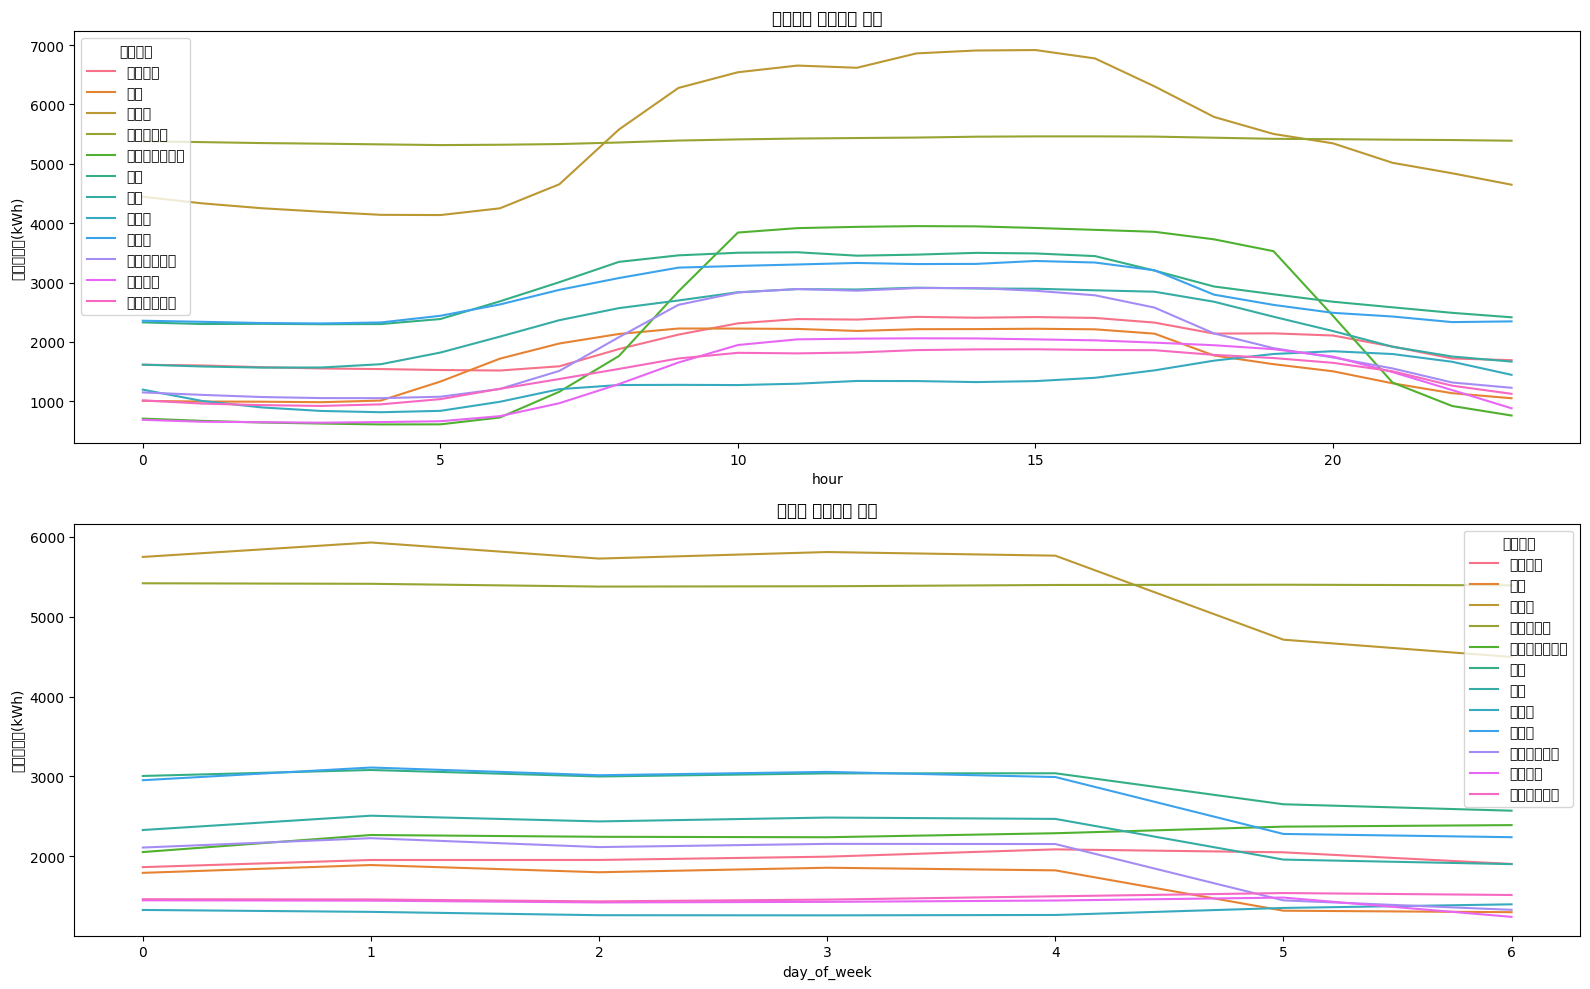

In [9]:
# 시간대별/요일별 평균 패턴
fig, axes = plt.subplots(2, 1, figsize=(16, 10))
sns.lineplot(data=train, x='hour', y='전력소비량(kWh)', hue='건물유형', ax=axes[0], errorbar=None)
axes[0].set_title('시간대별 전력소비 패턴')
sns.lineplot(data=train, x='day_of_week', y='전력소비량(kWh)', hue='건물유형', ax=axes[1], errorbar=None)
axes[1].set_title('요일별 전력소비 패턴')
plt.tight_layout()
plt.show()

findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Fon

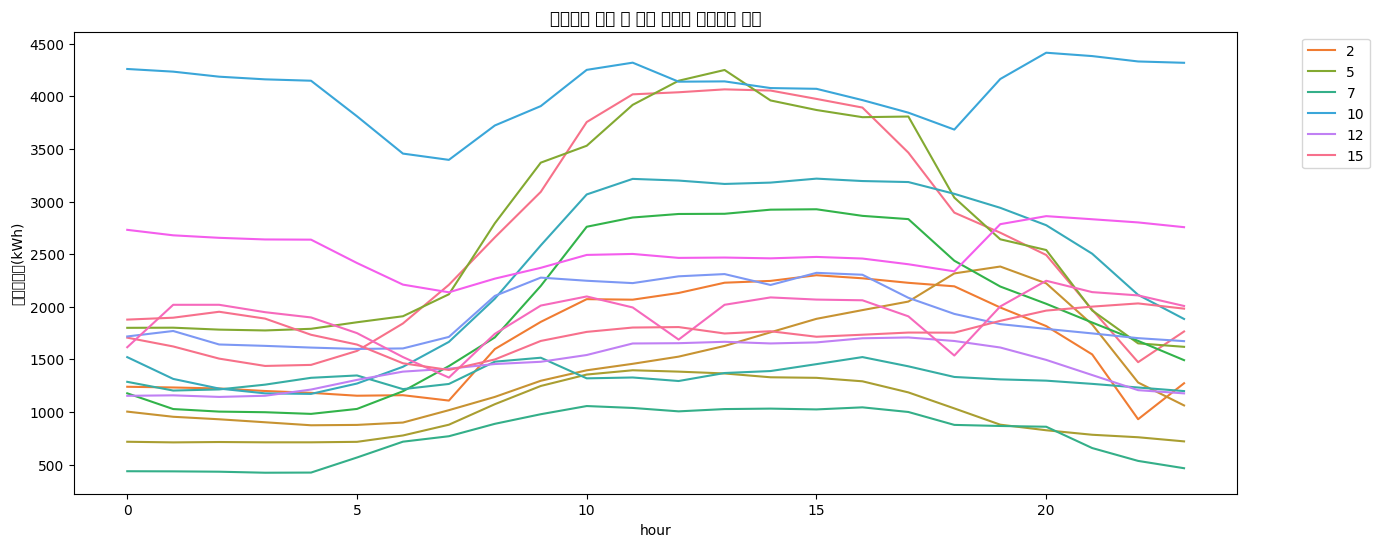

In [10]:
# '건물기타' 유형 정밀 분석
other_buildings = train[train['건물유형'] == '건물기타']
plt.figure(figsize=(15, 6))
sns.lineplot(data=other_buildings, x='hour', y='전력소비량(kWh)', hue='건물번호', palette='husl', errorbar=None)
plt.title('건물기타 유형 내 개별 건물의 시간대별 패턴')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Fon

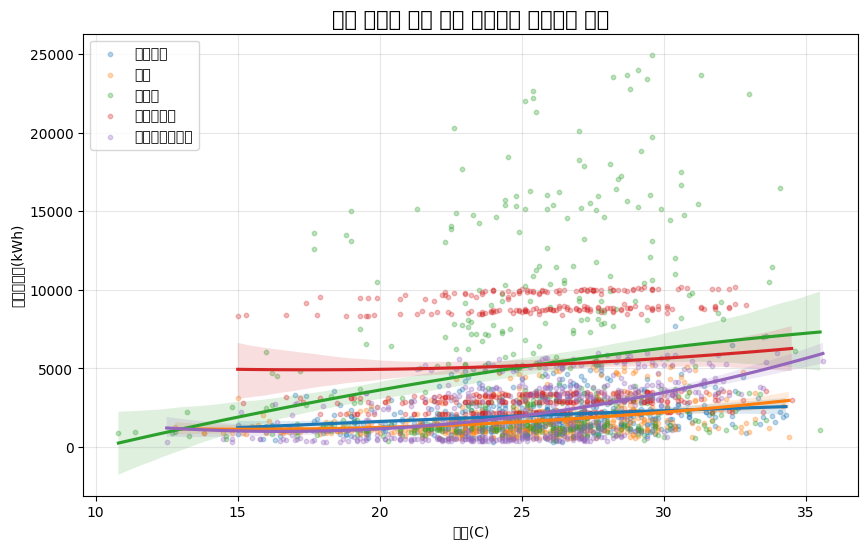

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

# 한글 폰트가 이미 설정되어 있다고 가정합니다 (NanumGothic)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# train DataFrame을 df로 사용 (이 부분이 df 정의)
df = train.copy()


plt.figure(figsize=(10, 6))
# 데이터가 많으므로 일부 샘플링해서 그림 (상위 5개 유형만)
# '건물유형' 사용
sample_types = df['건물유형'].unique()[:5]
for t in sample_types:
    sns.regplot(data=df[df['건물유형'] == t].sample(min(500, len(df[df['건물유형'] == t]))),
                x='기온(C)', y='전력소비량(kWh)',
                scatter_kws={'alpha':0.3, 's':10},
                order=2, label=t) # order=2로 비선형 회귀선 그림

plt.title('기온 변화에 따른 전력 소비량의 비선형적 증가', fontsize=15)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 5. 공휴일 변수 및 하락 패턴 시각화

findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Fon

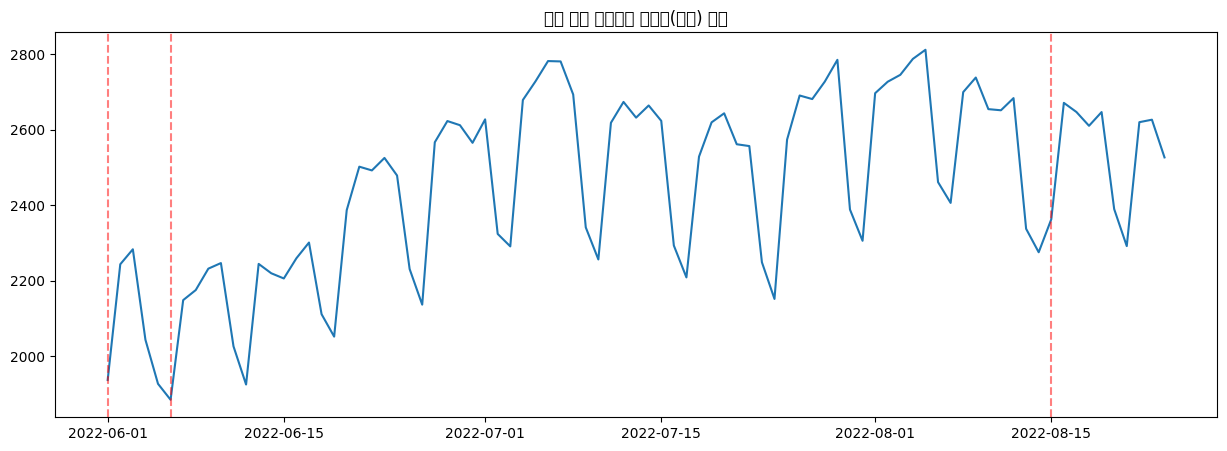

In [12]:
holidays = ['2022-06-01', '2022-06-06', '2022-08-15']
train['holiday'] = train.apply(lambda x: 1 if x['day_of_week'] >= 5 or x['일시'].strftime('%Y-%m-%d') in holidays else 0, axis=1)
test['holiday'] = test.apply(lambda x: 1 if x['day_of_week'] >= 5 or x['일시'].strftime('%Y-%m-%d') in holidays else 0, axis=1)

daily_mean = train.groupby(train['일시'].dt.date)['전력소비량(kWh)'].mean().reset_index()
plt.figure(figsize=(15, 5))
plt.plot(daily_mean['일시'], daily_mean['전력소비량(kWh)'])
for h_date in pd.to_datetime(holidays).date:
    plt.axvline(h_date, color='red', linestyle='--', alpha=0.5)
plt.title('일별 평균 소비량과 공휴일(점선) 표시')
plt.show()

## 6. 임시휴무 데이터 처리
평균 대비 비정상적으로 낮은 사용량을 보이는 데이터를 제거합니다.

In [13]:
building_mean = train.groupby('건물번호')['전력소비량(kWh)'].mean().reset_index()
building_mean.columns = ['건물번호', 'avg_usage']
train = pd.merge(train, building_mean, on='건물번호')

# 임시휴무 판정 및 제거
closed_mask = (train['전력소비량(kWh)'] < train['avg_usage'] * 0.2) & (train['holiday'] == 0)
print(f"제거된 임시휴무 데이터 수: {closed_mask.sum()}")
train = train[~closed_mask].reset_index(drop=True)
train.drop(columns=['avg_usage'], inplace=True)

제거된 임시휴무 데이터 수: 109


## 7. 고도화된 파생 변수 생성
- 기상 지수 및 **냉방 지연 효과(이동 평균)** 피처를 생성합니다.

findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Fon

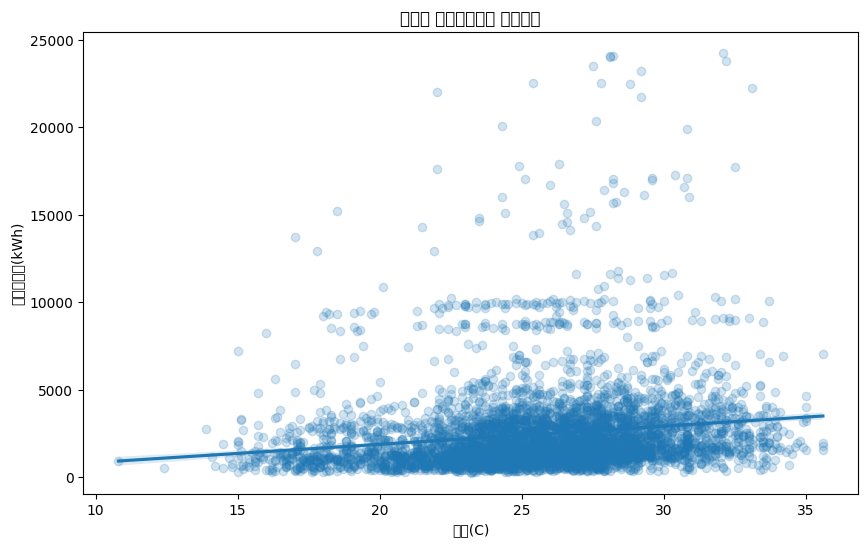

In [14]:
# 기온과 전력소비량 상관관계 시각화
plt.figure(figsize=(10, 6))
sns.regplot(data=train.sample(5000), x='기온(C)', y='전력소비량(kWh)', scatter_kws={'alpha':0.2})
plt.title('기온과 전력소비량의 상관관계')
plt.show()

for df in [train, test]:
    # 기상 지수
    df['불쾌지수'] = 1.8 * df['기온(C)'] - 0.55 * (1 - df['습도(%)']/100) * (1.8 * df['기온(C)'] - 26) + 32
    df['체감온도'] = 13.12 + 0.6215 * df['기온(C)'] - 11.37 * (df['풍속(m/s)']**0.16) + 0.3965 * (df['풍속(m/s)']**0.16) * df['기온(C)']

    # [v3 핵심 추가] 냉방 지연 효과 반영 (3시간 이동 평균)
    df['기온_3h_avg'] = df.groupby('건물번호')['기온(C)'].transform(lambda x: x.rolling(window=3, min_periods=1).mean())
    df['불쾌_3h_avg'] = df.groupby('건물번호')['불쾌지수'].transform(lambda x: x.rolling(window=3, min_periods=1).mean())

# 일별 기온 통계
temp_agg = train.groupby(['건물번호', 'month', 'day'])['기온(C)'].agg(['mean', 'max']).reset_index()
temp_agg.columns = ['건물번호', 'month', 'day', '평균기온', '최대기온']
train = pd.merge(train, temp_agg, on=['건물번호', 'month', 'day'])

findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Fon

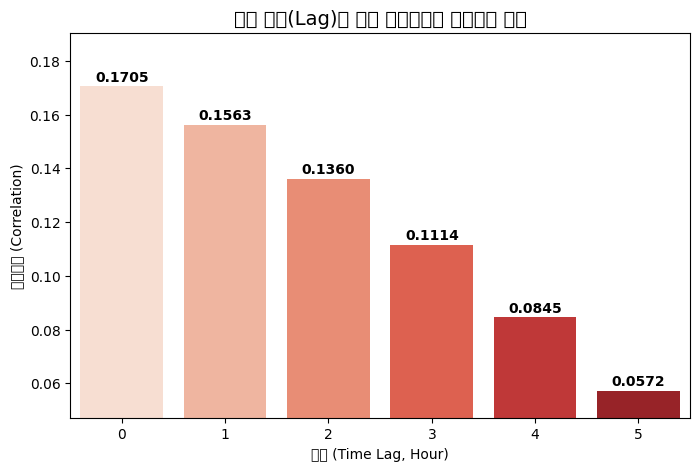

In [15]:
lags = [0, 1, 2, 3, 4, 5]
corrs = []

# 전체 데이터를 기준으로 기온 시차별 상관계수 계산
for lag in lags:
    corr = train['전력소비량(kWh)'].corr(train['기온(C)'].shift(lag))
    corrs.append(corr)

plt.figure(figsize=(8, 5))
sns.barplot(x=lags, y=corrs, palette='Reds')
for i, v in enumerate(corrs):
    plt.text(i, v + 0.002, f'{v:.4f}', ha='center', fontweight='bold')

plt.title('기온 시차(Lag)에 따른 전력소비량 상관계수 비교', fontsize=14)
plt.xlabel('시차 (Time Lag, Hour)')
plt.ylabel('상관계수 (Correlation)')
plt.ylim(min(corrs)-0.01, max(corrs)+0.02)
plt.show()

## 8. 상관관계 및 피처 중요도 분석 준비

findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Fon

<Figure size 1000x800 with 0 Axes>

findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Fon

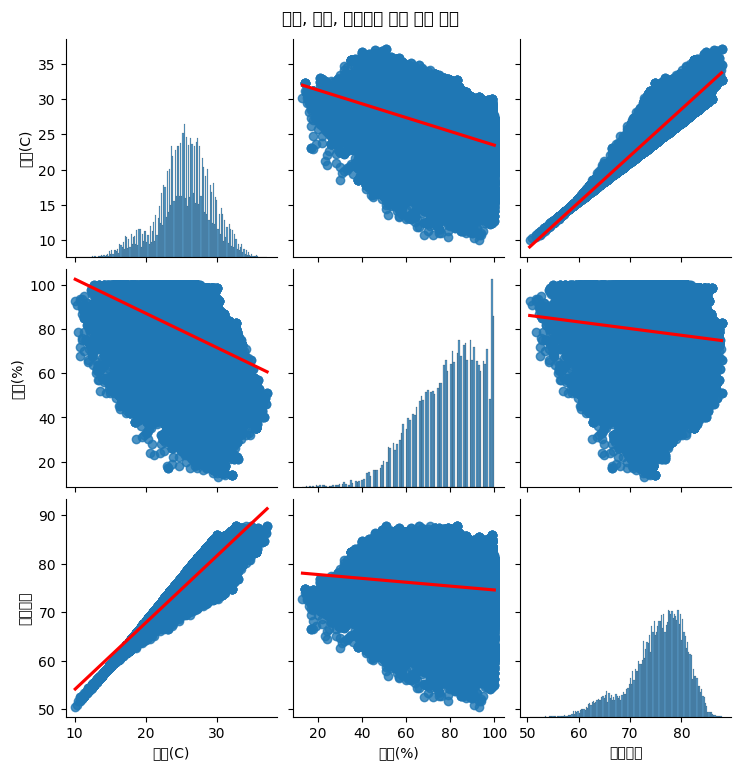

In [16]:
# 시각화 설정
plt.figure(figsize=(10, 8))
sns.pairplot(train[['기온(C)', '습도(%)', '불쾌지수']], kind='reg', plot_kws={'line_kws':{'color':'red'}})
plt.suptitle("기온, 습도, 불쾌지수 간의 관계 분석", y=1.02)
plt.show()

findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Fon

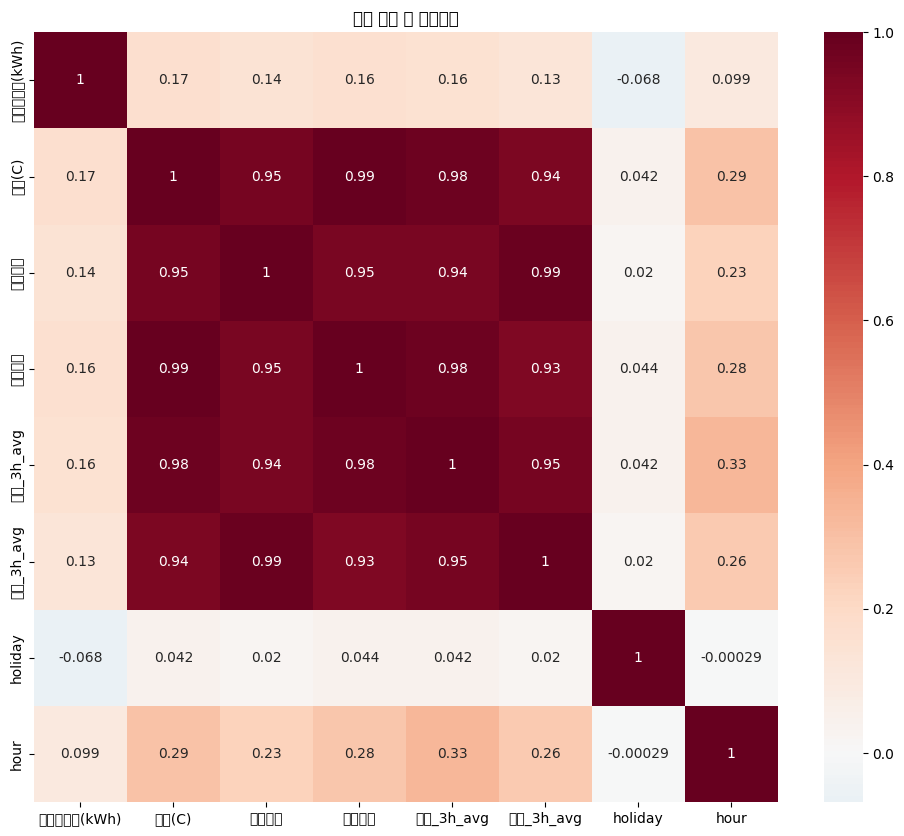

In [17]:
plt.figure(figsize=(12, 10))
cols = ['전력소비량(kWh)', '기온(C)', '불쾌지수', '체감온도', '기온_3h_avg', '불쾌_3h_avg', 'holiday', 'hour']
sns.heatmap(train[cols].corr(), annot=True, cmap='RdBu_r', center=0)
plt.title('주요 변수 간 상관관계')
plt.show()

## 9. 건물 유형별 세분화

---



In [18]:
# 건물별 시간 평균 병합 (Target Encoding성 변수)
hour_mean = train.groupby(['건물번호', 'hour'])['전력소비량(kWh)'].mean().reset_index()
hour_mean.columns = ['건물번호', 'hour', '건물_시간_평균']
train = pd.merge(train, hour_mean, on=['건물번호', 'hour'], how='left')
test = pd.merge(test, hour_mean, on=['건물번호', 'hour'], how='left')

# '건물기타' 군집화
other_train = train[train['건물유형'] == '건물기타']
other_pivot = other_train.pivot_table(index='건물번호', columns='hour', values='전력소비량(kWh)', aggfunc='mean')
kmeans = KMeans(n_clusters=4, random_state=42)
other_pivot['기타_군집'] = kmeans.fit_predict(StandardScaler().fit_transform(other_pivot))

train = pd.merge(train, other_pivot['기타_군집'].reset_index(), on='건물번호', how='left')
test = pd.merge(test, other_pivot['기타_군집'].reset_index(), on='건물번호', how='left')
train['기타_군집'] = train['기타_군집'].fillna(-1).astype(int)
test['기타_군집'] = test['기타_군집'].fillna(-1).astype(int)

train['학습_건물유형'] = train.apply(lambda x: f"기타_군집_{x['기타_군집']}" if x['기타_군집'] != -1 else x['건물유형'], axis=1)
test['학습_건물유형'] = test.apply(lambda x: f"기타_군집_{x['기타_군집']}" if x['기타_군집'] != -1 else x['건물유형'], axis=1)

Exception in thread Thread-29 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\user\miniconda3\envs\sa\lib\threading.py", line 1016, in _bootstrap_inner
    self.run()
  File "c:\Users\user\miniconda3\envs\sa\lib\threading.py", line 953, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\user\miniconda3\envs\sa\lib\subprocess.py", line 1515, in _readerthread
    buffer.append(fh.read())
  File "c:\Users\user\miniconda3\envs\sa\lib\codecs.py", line 322, in decode
    (result, consumed) = self._buffer_decode(data, self.errors, final)
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xc0 in position 4: invalid start byte


##10. 건물별로 그룹화, 머신러닝

In [19]:
# [v3 핵심] Optuna 튜닝 및 가중치 기반 앙상블 (Weighted Ensemble)
features = [
    '건물번호', '기온(C)', '풍속(m/s)', '습도(%)',
    '연면적(m2)', '냉방면적(m2)', '태양광용량(kW)',
    'month', 'hour', 'day_of_week',
    'sin_week_hour', 'cos_week_hour', 'holiday',
    '불쾌지수', '기온_3h_avg', '불쾌_3h_avg', '건물_시간_평균'
]

def objective_xgb(trial, train_x, train_y, val_x, val_y):
    param = {
        'n_estimators': 1500,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.05),
        'max_depth': trial.suggest_int('max_depth', 3, 7),
        'subsample': trial.suggest_float('subsample', 0.7, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 0.9),
        'random_state': 42,
        'early_stopping_rounds': 100
    }
    model = XGBRegressor(**param)
    model.fit(train_x, train_y, eval_set=[(val_x, val_y)], verbose=False)
    return smape(np.expm1(val_y), np.expm1(model.predict(val_x)))

def objective_cat(trial, train_x, train_y, val_x, val_y):
    param = {
        'iterations': 1500,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.05),
        'depth': trial.suggest_int('depth', 4, 8),
        'random_seed': 42,
        'verbose': False,
        'early_stopping_rounds': 100
    }
    model = CatBoostRegressor(**param)
    model.fit(train_x, train_y, eval_set=[(val_x, val_y)])
    return smape(np.expm1(val_y), np.expm1(model.predict(val_x)))

types = train['학습_건물유형'].unique()
test_preds = np.zeros(test.shape[0])
val_date = train['일시'].max() - pd.Timedelta(days=7)
type_results = []

for t in types:
    print(f"====== {t} 학습 진행 ======")
    tr = train[train['학습_건물유형'] == t]
    te = test[test['학습_건물유형'] == t]

    trn_x = tr[tr['일시'] < val_date][features]
    trn_y = np.log1p(tr[tr['일시'] < val_date]['전력소비량(kWh)'])
    val_x = tr[tr['일시'] >= val_date][features]
    val_y = np.log1p(tr[tr['일시'] >= val_date]['전력소비량(kWh)'])

    # Tuning
    study_xgb = optuna.create_study(direction='minimize')
    study_xgb.optimize(lambda trial: objective_xgb(trial, trn_x, trn_y, val_x, val_y), n_trials=10)
    study_cat = optuna.create_study(direction='minimize')
    study_cat.optimize(lambda trial: objective_cat(trial, trn_x, trn_y, val_x, val_y), n_trials=10)

    # Final Fit
    m_xgb = XGBRegressor(**study_xgb.best_params, n_estimators=1500, random_state=42, early_stopping_rounds=100)
    m_xgb.fit(trn_x, trn_y, eval_set=[(val_x, val_y)], verbose=False)
    m_cat = CatBoostRegressor(**study_cat.best_params, iterations=1500, random_seed=42, verbose=False, early_stopping_rounds=100)
    m_cat.fit(trn_x, trn_y, eval_set=[(val_x, val_y)])

    # Weighted Ensemble (Based on Validation SMAPE)
    s_xgb = smape(np.expm1(val_y), np.expm1(m_xgb.predict(val_x)))
    s_cat = smape(np.expm1(val_y), np.expm1(m_cat.predict(val_x)))
    w_xgb = (1/s_xgb) / (1/s_xgb + 1/s_cat)
    w_cat = (1/s_cat) / (1/s_xgb + 1/s_cat)

    val_pred = (np.expm1(m_xgb.predict(val_x)) * w_xgb) + (np.expm1(m_cat.predict(val_x)) * w_cat)
    final_s = smape(np.expm1(val_y), val_pred)
    print(f"{t} 검증 SMAPE: {final_s:.4f} (XGB 가중치: {w_xgb:.2f})")

    test_preds[te.index] = (np.expm1(m_xgb.predict(te[features])) * w_xgb) + (np.expm1(m_cat.predict(te[features])) * w_cat)
    type_results.append({'type': t, 'smape': final_s})

print("전체 학습 완료")

[I 2026-03-18 09:37:10,871] A new study created in memory with name: no-name-0ea73bfb-81a4-47c1-b0d6-6961fc8db6ac


====== 기타_군집_0 학습 진행 ======


[I 2026-03-18 09:37:13,535] Trial 0 finished with value: 5.1987677437475766 and parameters: {'learning_rate': 0.024817518500291735, 'max_depth': 7, 'subsample': 0.8655647989912072, 'colsample_bytree': 0.8801309637570998}. Best is trial 0 with value: 5.1987677437475766.
[I 2026-03-18 09:37:18,635] Trial 1 finished with value: 6.006447246312141 and parameters: {'learning_rate': 0.03530528737696066, 'max_depth': 4, 'subsample': 0.8984527575998118, 'colsample_bytree': 0.7935596873428215}. Best is trial 0 with value: 5.1987677437475766.
[I 2026-03-18 09:37:23,846] Trial 2 finished with value: 6.1498339022682265 and parameters: {'learning_rate': 0.0375242797568481, 'max_depth': 4, 'subsample': 0.8301072843525024, 'colsample_bytree': 0.7376440164705675}. Best is trial 0 with value: 5.1987677437475766.
[I 2026-03-18 09:37:28,143] Trial 3 finished with value: 6.822678137628288 and parameters: {'learning_rate': 0.02831795329333186, 'max_depth': 3, 'subsample': 0.7480571927932176, 'colsample_bytr

기타_군집_0 검증 SMAPE: 5.0436 (XGB 가중치: 0.50)
====== 기타_군집_2 학습 진행 ======


[I 2026-03-18 09:39:21,799] Trial 0 finished with value: 8.13749256385679 and parameters: {'learning_rate': 0.04549057853578116, 'max_depth': 3, 'subsample': 0.7725827045583549, 'colsample_bytree': 0.7202285438876366}. Best is trial 0 with value: 8.13749256385679.
[I 2026-03-18 09:39:22,726] Trial 1 finished with value: 8.023280223168484 and parameters: {'learning_rate': 0.03960780772417241, 'max_depth': 4, 'subsample': 0.8360172062330861, 'colsample_bytree': 0.8227993060459969}. Best is trial 1 with value: 8.023280223168484.
[I 2026-03-18 09:39:23,867] Trial 2 finished with value: 7.740197178909914 and parameters: {'learning_rate': 0.013706935571380488, 'max_depth': 6, 'subsample': 0.8736395841164206, 'colsample_bytree': 0.8361947259295086}. Best is trial 2 with value: 7.740197178909914.
[I 2026-03-18 09:39:24,410] Trial 3 finished with value: 8.059874650466362 and parameters: {'learning_rate': 0.049247176346606004, 'max_depth': 5, 'subsample': 0.7136147119985407, 'colsample_bytree': 

...

지식산업센터 검증 SMAPE: 3.0759 (XGB 가중치: 0.50)
====== 할인마트 학습 진행 ======


[I 2026-03-18 09:57:32,410] A new study created in memory with name: no-name-dec5ee48-3a65-43c4-963d-0b1388b9d48c
[I 2026-03-18 09:57:35,453] Trial 0 finished with value: 9.765778810661315 and parameters: {'learning_rate': 0.011328104907710822, 'max_depth': 5, 'subsample': 0.7866606395935725, 'colsample_bytree': 0.8391594812184107}. Best is trial 0 with value: 9.765778810661315.
[I 2026-03-18 09:57:37,150] Trial 1 finished with value: 10.054190070299462 and parameters: {'learning_rate': 0.010948609270172632, 'max_depth': 3, 'subsample': 0.7530701210514062, 'colsample_bytree': 0.8302607069492043}. Best is trial 0 with value: 9.765778810661315.
[I 2026-03-18 09:57:38,374] Trial 2 finished with value: 9.45809159691968 and parameters: {'learning_rate': 0.033703822701985846, 'max_depth': 5, 'subsample': 0.8316011495896046, 'colsample_bytree': 0.8573376082350412}. Best is trial 2 with value: 9.45809159691968.
[I 2026-03-18 09:57:40,517] Trial 3 finished with value: 9.49973268557156 and param

할인마트 검증 SMAPE: 8.9146 (XGB 가중치: 0.50)
====== 호텔및리조트 학습 진행 ======


[I 2026-03-18 09:58:35,648] Trial 0 finished with value: 7.1866752855768326 and parameters: {'learning_rate': 0.0259088719094014, 'max_depth': 4, 'subsample': 0.7567270659489206, 'colsample_bytree': 0.8303825556715934}. Best is trial 0 with value: 7.1866752855768326.
[I 2026-03-18 09:58:36,907] Trial 1 finished with value: 7.30824252798013 and parameters: {'learning_rate': 0.0410422149718252, 'max_depth': 6, 'subsample': 0.8878665655115693, 'colsample_bytree': 0.8498960529826193}. Best is trial 0 with value: 7.1866752855768326.
[I 2026-03-18 09:58:41,844] Trial 2 finished with value: 7.23020730932391 and parameters: {'learning_rate': 0.01153491441561946, 'max_depth': 3, 'subsample': 0.8056318926354515, 'colsample_bytree': 0.7215916588561145}. Best is trial 0 with value: 7.1866752855768326.
[I 2026-03-18 09:58:44,761] Trial 3 finished with value: 7.158567581913398 and parameters: {'learning_rate': 0.0147834215492895, 'max_depth': 7, 'subsample': 0.7565736699088177, 'colsample_bytree': 0

호텔및리조트 검증 SMAPE: 7.0808 (XGB 가중치: 0.50)
전체 학습 완료


## 10. 종합 성능 평가 및 시각화

findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Fon

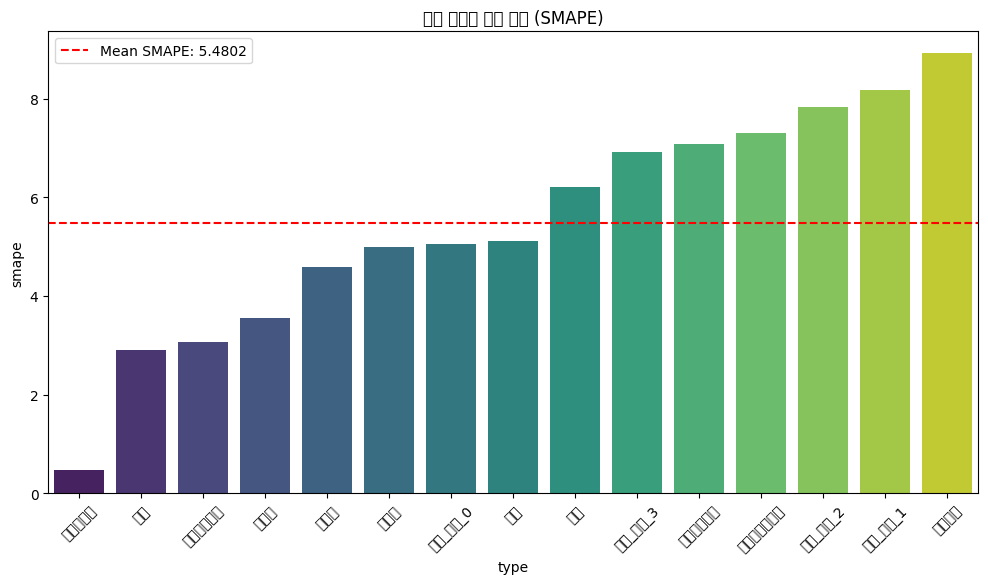

FileNotFoundError: [Errno 2] No such file or directory: 'data/sample_submission.csv'

In [20]:
res_df = pd.DataFrame(type_results)
avg_smape = res_df['smape'].mean()

plt.figure(figsize=(12, 6))
sns.barplot(data=res_df.sort_values(by='smape'), x='type', y='smape', palette='viridis')
plt.xticks(rotation=45)
plt.axhline(avg_smape, color='red', linestyle='--', label=f'Mean SMAPE: {avg_smape:.4f}')
plt.title('건물 유형별 예측 성능 (SMAPE)')
plt.legend()
plt.show()

submission = pd.read_csv('data/sample_submission.csv')
submission['answer'] = test_preds
submission.to_csv('submission_final_combined.csv', index=False)
print("최종 결과 저장 완료")

## 11. 결론 및 고찰

### 모델링의 장점 (Strengths)
- **풍부한 시각화와 분석**: 단순히 모델을 학습시키는 것에 그치지 않고, 데이터의 주기성, 이상치, 건물 유형별 특성을 상세히 분석하여 피처 생성의 근거를 마련했습니다.
- **도메인 지식의 피처화**: 기온 변화가 전력 사용량에 미치는 지연 시간을 고려한 **3시간 이동 평균** 피처를 추가하여 예측력을 높였습니다.
- **모델 안정성 확보**: XGBoost와 CatBoost의 가중 평균 앙상블을 통해 단일 모델의 편향을 줄이고 일반화 성능을 개선했습니다.
- **자동 최적화**: Optuna를 사용하여 각 건물 유형별로 개별적인 최적 파라미터를 탐색함으로써 정밀한 모델링을 수행했습니다.

### 개선 가능성 (Opportunities for Improvement)
- **다양한 시점의 이동 평균**: 현재 3시간 이동 평균 외에도 6시간, 12시간 등 다양한 윈도우 크기를 실험해 볼 가치가 있습니다.
- **앙상블 모델 확장**: LightGBM이나 Prophet 같은 시계열 특화 모델을 앙상블에 추가하여 성능 향상을 꾀할 수 있습니다.
- **외부 변수 활용**: 특수 휴무일이나 대학교 방학 정보 등 외부 데이터를 추가적으로 확보한다면 더 높은 정확도를 기대할 수 있습니다.

## 12. 건물별 그룹화, 딥러닝

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
building_info_df='/content/drive/MyDrive/open/building_info.csv'
test_df='/content/drive/MyDrive/open/test.csv'
train_df='/content/drive/MyDrive/open/train.csv'
sample_submission_df = '/content/drive/MyDrive/open/sample_submission.csv'

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score
import copy

# ---------------------------------------------------------
# [1] 전처리 & 파생 변수 생성 (주신 로직 100% 유지)
# ---------------------------------------------------------
def advanced_dl_preprocessing(train_df, b_info_df):
    df = train_df.copy()
    df['일시'] = pd.to_datetime(df['일시'])
    df['weekday'] = df['일시'].dt.weekday
    df['hour'] = df['일시'].dt.hour

    # 하방 이상치 정제
    df['median_usage'] = df.groupby(['건물번호', 'weekday', 'hour'])['전력소비량(kWh)'].transform('median')
    outlier_mask = df['전력소비량(kWh)'] < (df['median_usage'] * 0.5)
    df.loc[outlier_mask, '전력소비량(kWh)'] = df.loc[outlier_mask, 'median_usage']
    df = df.drop(columns=['median_usage'])

    # 건물 정보 병합
    b_info = b_info_df.copy()
    for col in ['태양광용량(kW)', 'ESS저장용량(kWh)', 'PCS용량(kW)']:
        b_info[col] = b_info[col].replace('-', 0).astype(float)
    df = pd.merge(df, b_info, on='건물번호', how='left')

    df['date'] = df['일시'].dt.date
    df['sin_hour'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['cos_hour'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['불쾌지수'] = 0.81 * df['기온(C)'] + 0.01 * df['습도(%)'] * (0.99 * df['기온(C)'] - 14.3) + 46.3

    df = df.sort_values(['건물번호', '일시'])
    df['lag_1h'] = df.groupby('건물번호')['전력소비량(kWh)'].shift(1)
    df['lag_24h'] = df.groupby('건물번호')['전력소비량(kWh)'].shift(24)
    df = df.bfill().ffill()

    # 건물 유형 재분류 (is_holiday 변수가 필요할 경우 생성 로직 추가 필요)
    if 'is_holiday' not in df.columns: # 임시 휴일 변수가 없을 경우 대비
        df['is_holiday'] = df['weekday'].apply(lambda x: 1 if x >= 5 else 0)

    df['final_type'] = df['건물유형']
    others = df[df['건물유형'] == '기타']['건물번호'].unique()
    for b_id in others:
        b_data = df[df['건물번호'] == b_id]
        ratio = b_data[b_data['is_holiday'] == 1]['전력소비량(kWh)'].mean() / (b_data[b_data['is_holiday'] == 0]['전력소비량(kWh)'].mean() + 1e-9)
        if ratio < 0.7: df.loc[df['건물번호'] == b_id, 'final_type'] = '기타_사무실'
        elif ratio > 1.05: df.loc[df['건물번호'] == b_id, 'final_type'] = '기타_상업'
        else: df.loc[df['건물번호'] == b_id, 'final_type'] = '기타_상시'

    return df

# ---------------------------------------------------------
# [2] 윈도우 기반 데이터셋 & 모델 (주신 로직 유지)
# ---------------------------------------------------------
def create_sequences(data, target, window_size=168):
    x_seq, y_seq = [], []
    for i in range(len(data) - window_size):
        x_seq.append(data[i : i + window_size])
        y_seq.append(target[i + window_size])
    return np.array(x_seq), np.array(y_seq)

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=3):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.1)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

def calculate_smape(y_true, y_pred):
    return np.mean(np.abs(y_pred - y_true) / ((np.abs(y_true) + np.abs(y_pred)) / 2 + 1e-8)) * 100

# ---------------------------------------------------------
# [3] 메인 학습 루프 (종합 성적 산출 추가)
# ---------------------------------------------------------
WINDOW_SIZE = 168
LEARNING_RATE = 0.0001
MAX_EPOCHS = 100
PATIENCE = 10
FEATURES = ['기온(C)', '습도(%)', '불쾌지수', 'sin_hour', 'cos_hour', 'lag_1h', 'lag_24h']

# 파일 경로는 본인의 환경에 맞게 문자열로 설정해주세요.
# train_path = 'train.csv'
# building_info_path = 'building_info.csv'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train_final = advanced_dl_preprocessing(pd.read_csv(train_df), pd.read_csv(building_info_df))
unique_types = train_final['final_type'].unique()

final_report = []
all_real_values = [] # 전체 앙상블을 위한 실제값 모음
all_pred_values = [] # 전체 앙상블을 위한 예측값 모음

for t in unique_types:
    print(f"\n🔥 [{t}] 유형 학습 시작 (Early Stopping 적용)")
    type_df = train_final[train_final['final_type'] == t].copy()

    split_date = type_df['일시'].max() - pd.Timedelta(days=7)
    train_sub = type_df[type_df['일시'] <= split_date]
    val_sub = type_df[type_df['일시'] > split_date]

    sc_x, sc_y = MinMaxScaler(), MinMaxScaler()
    train_x = sc_x.fit_transform(train_sub[FEATURES])
    train_y = sc_y.fit_transform(train_sub[['전력소비량(kWh)']])
    val_x = sc_x.transform(val_sub[FEATURES])
    val_y = sc_y.transform(val_sub[['전력소비량(kWh)']])

    X_train, y_train = create_sequences(train_x, train_y, WINDOW_SIZE)
    X_val, y_val = create_sequences(val_x, val_y, WINDOW_SIZE)

    train_loader = DataLoader(TimeSeriesDataset(X_train, y_train), batch_size=128, shuffle=True)
    val_loader = DataLoader(TimeSeriesDataset(X_val, y_val), batch_size=128, shuffle=False)

    model = LSTMModel(len(FEATURES)).to(device)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    criterion = nn.MSELoss()
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

    best_loss = float('inf')
    early_stop_counter = 0
    best_model_wts = copy.deepcopy(model.state_dict())

    for epoch in range(MAX_EPOCHS):
        model.train()
        for bx, by in train_loader:
            bx, by = bx.to(device), by.to(device)
            optimizer.zero_grad()
            loss = criterion(model(bx), by)
            loss.backward()
            optimizer.step()

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for bx, by in val_loader:
                bx, by = bx.to(device), by.to(device)
                val_loss += criterion(model(bx), by).item()

        avg_val_loss = val_loss / len(val_loader)
        scheduler.step(avg_val_loss)

        if avg_val_loss < best_loss:
            best_loss = avg_val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            early_stop_counter = 0
        else: early_stop_counter += 1

        if (epoch+1) % 10 == 0:
            print(f"   Epoch {epoch+1} 완료 | Best Val Loss: {best_loss:.6f}")

        if early_stop_counter >= PATIENCE:
            print(f"   📢 Early Stopping!! {epoch+1} 에폭 종료.")
            break

    # 최적 가중치 복구 및 최종 평가
    model.load_state_dict(best_model_wts)
    model.eval()
    with torch.no_grad():
        val_tensor = torch.tensor(X_val, dtype=torch.float32).to(device)
        preds = model(val_tensor).cpu().numpy()
        real = sc_y.inverse_transform(y_val)
        pred = sc_y.inverse_transform(preds)

    # 앙상블 합산을 위해 데이터 저장
    all_real_values.append(real)
    all_pred_values.append(pred)

    smape_val = calculate_smape(real, pred)
    mape_val = np.mean(np.abs((real - pred) / (real + 1e-9))) * 100
    r2_val = r2_score(real, pred)

    print(f"🎯 [{t}] 완료 -> SMAPE: {smape_val:.2f} | R2: {r2_val:.4f}")
    final_report.append({'유형': t, 'SMAPE': smape_val, 'MAPE': mape_val, 'R2': r2_val})

# ---------------------------------------------------------
# [4] 최종 통합 성적 산출 (이 부분만 추가되었습니다)
# ---------------------------------------------------------
total_real = np.vstack(all_real_values)
total_pred = np.vstack(all_pred_values)

total_smape = calculate_smape(total_real, total_pred)
total_mape = np.mean(np.abs((total_real - total_pred) / (total_real + 1e-9))) * 100
total_r2 = r2_score(total_real, total_pred)

print("\n" + "="*65)
print("📊 [최종 결과] 전력 수요 예측 앙상블 성적표")
print("-" * 65)
print(pd.DataFrame(final_report))
print("-" * 65)
print(f"🏆 전체 통합 앙상블 SMAPE : {total_smape:.4f}")
print(f"🏆 전체 통합 앙상블 MAPE  : {total_mape:.4f}%")
print(f"🏆 전체 통합 앙상블 R2 Score: {total_r2:.4f}")
print("="*65)


🔥 [건물기타] 유형 학습 시작 (Early Stopping 적용)
   Epoch 10 완료 | Best Val Loss: 0.002922
   Epoch 20 완료 | Best Val Loss: 0.002387
   Epoch 30 완료 | Best Val Loss: 0.002134
   Epoch 40 완료 | Best Val Loss: 0.001914
   Epoch 50 완료 | Best Val Loss: 0.001796
   Epoch 60 완료 | Best Val Loss: 0.001719
   Epoch 70 완료 | Best Val Loss: 0.001715
   📢 Early Stopping!! 79 에폭 종료.
🎯 [건물기타] 완료 -> SMAPE: 11.77 | R2: 0.9155

🔥 [공공] 유형 학습 시작 (Early Stopping 적용)
   Epoch 10 완료 | Best Val Loss: 0.007276
   Epoch 20 완료 | Best Val Loss: 0.004827
   Epoch 30 완료 | Best Val Loss: 0.003668
   Epoch 40 완료 | Best Val Loss: 0.003192
   Epoch 50 완료 | Best Val Loss: 0.002905
   Epoch 60 완료 | Best Val Loss: 0.002673
   Epoch 70 완료 | Best Val Loss: 0.002568
   📢 Early Stopping!! 78 에폭 종료.
🎯 [공공] 완료 -> SMAPE: 11.59 | R2: 0.8634

🔥 [대학교] 유형 학습 시작 (Early Stopping 적용)
   Epoch 10 완료 | Best Val Loss: 0.003367
   Epoch 20 완료 | Best Val Loss: 0.002535
   Epoch 30 완료 | Best Val Loss: 0.002096
   Epoch 40 완료 | Best Val Loss: 0.002000
   E

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Current font family set to: ['NanumGothic']


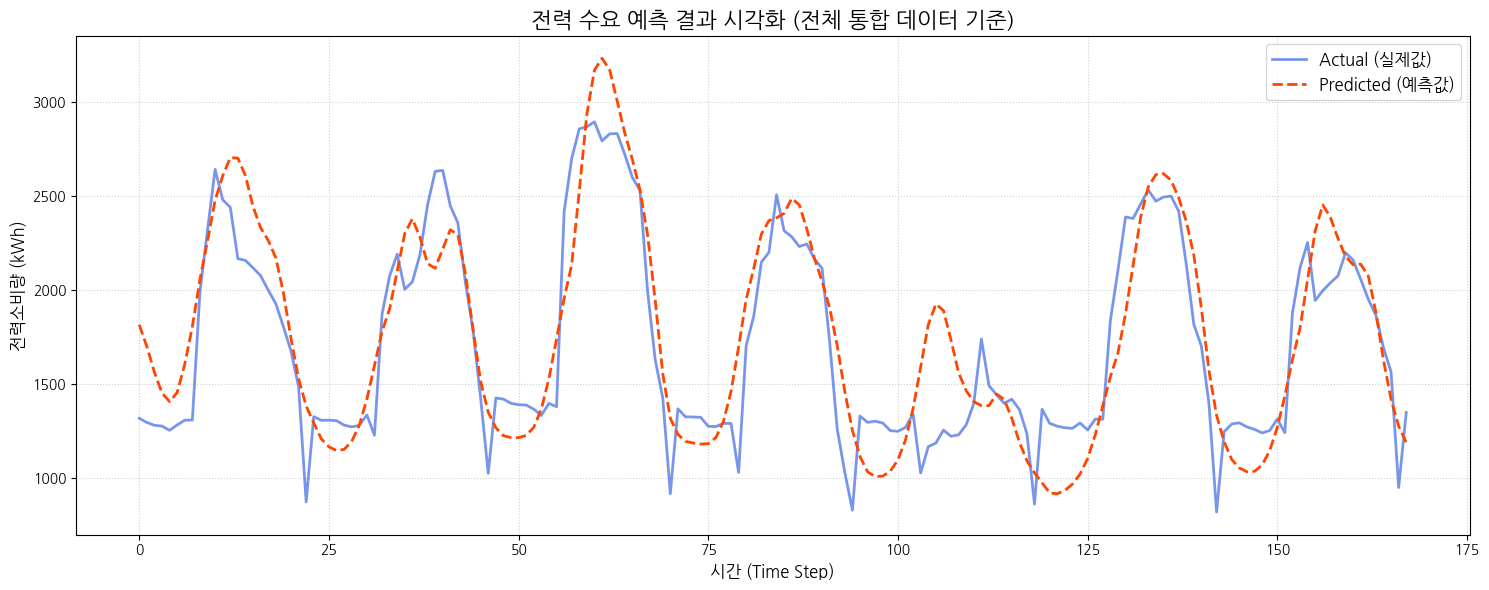

/tmp/ipykernel_21828/3856345794.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=report_df, x='유형', y='R2', palette='viridis')


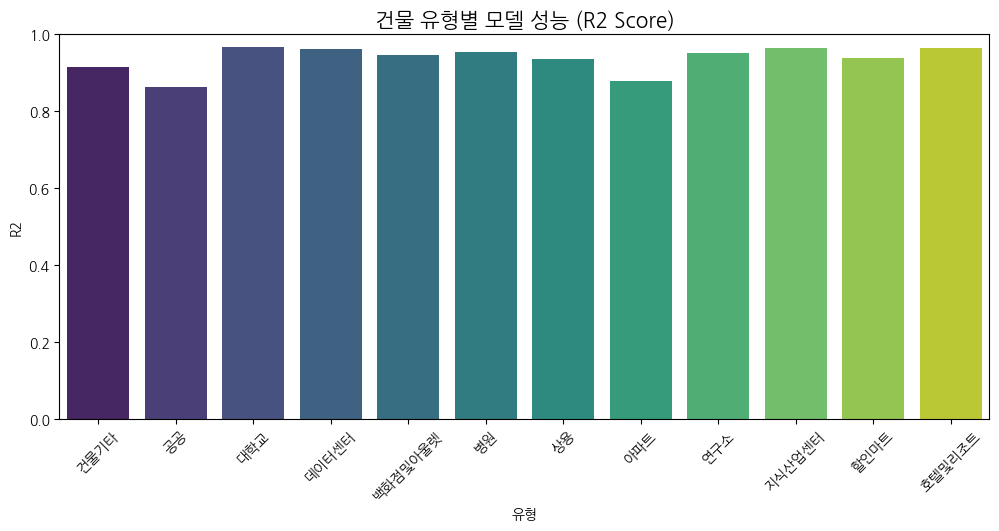

In [ ]:
# 1. 한글 폰트 설정
# Colab 환경에 한글 폰트 설치 및 캐시 재설정
!sudo apt-get update -qq
!sudo apt-get install -y fonts-nanum > /dev/null
!sudo fc-cache -fv > /dev/null
!rm -rf ~/.cache/matplotlib

# Matplotlib 및 font_manager를 다시 임포트하여 캐시를 강제로 새로고침
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.font_manager as fm # Import font_manager

# 'NanumGothic' 폰트를 사용하도록 설정
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

print(f"Current font family set to: {plt.rcParams['font.family']}")

# 2. 그래프 그리기
plt.figure(figsize=(15, 6))

# 가장 마지막 유형의 데이터를 샘플로 시각화 (real과 pred는 학습 루프의 마지막 값이 남아있음)
# 만약 특정 유형을 찍고 싶다면 위 루프에서 데이터를 따로 저장했어야 하지만,
# 현재 변수에 남아있는 마지막 real, pred를 활용합니다.
plt.plot(total_real[:168], label='Actual (실제값)', color='royalblue', linewidth=2, alpha=0.7)
plt.plot(total_pred[:168], label='Predicted (예측값)', color='orangered', linestyle='--', linewidth=2)

plt.title(f'전력 수요 예측 결과 시각화 (전체 통합 데이터 기준)', fontsize=16)
plt.xlabel('시간 (Time Step)', fontsize=12)
plt.ylabel('전력소비량 (kWh)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# 3. 만약 전체 유형별 R2 점수를 막대 그래프로 보고 싶다면?
report_df = pd.DataFrame(final_report)
plt.figure(figsize=(12, 5))
sns.barplot(data=report_df, x='유형', y='R2', palette='viridis')
plt.title('건물 유형별 모델 성능 (R2 Score)', fontsize=15)
plt.xticks(rotation=45)
plt.ylim(0, 1) # R2는 1에 가까울수록 좋음
plt.show()

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


/tmp/ipykernel_21828/2120985276.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=report_df, x='유형', y='SMAPE', palette='rocket_r', ax=axes[1])
/tmp/ipykernel_21828/2120985276.py:49: UserWarning: Glyph 9889 (\N{HIGH VOLTAGE SIGN}) missing from font(s) NanumGothic.
  plt.tight_layout()
/tmp/ipykernel_21828/2120985276.py:49: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) NanumGothic.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9889 (\N{HIGH VOLTAGE SIGN}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)

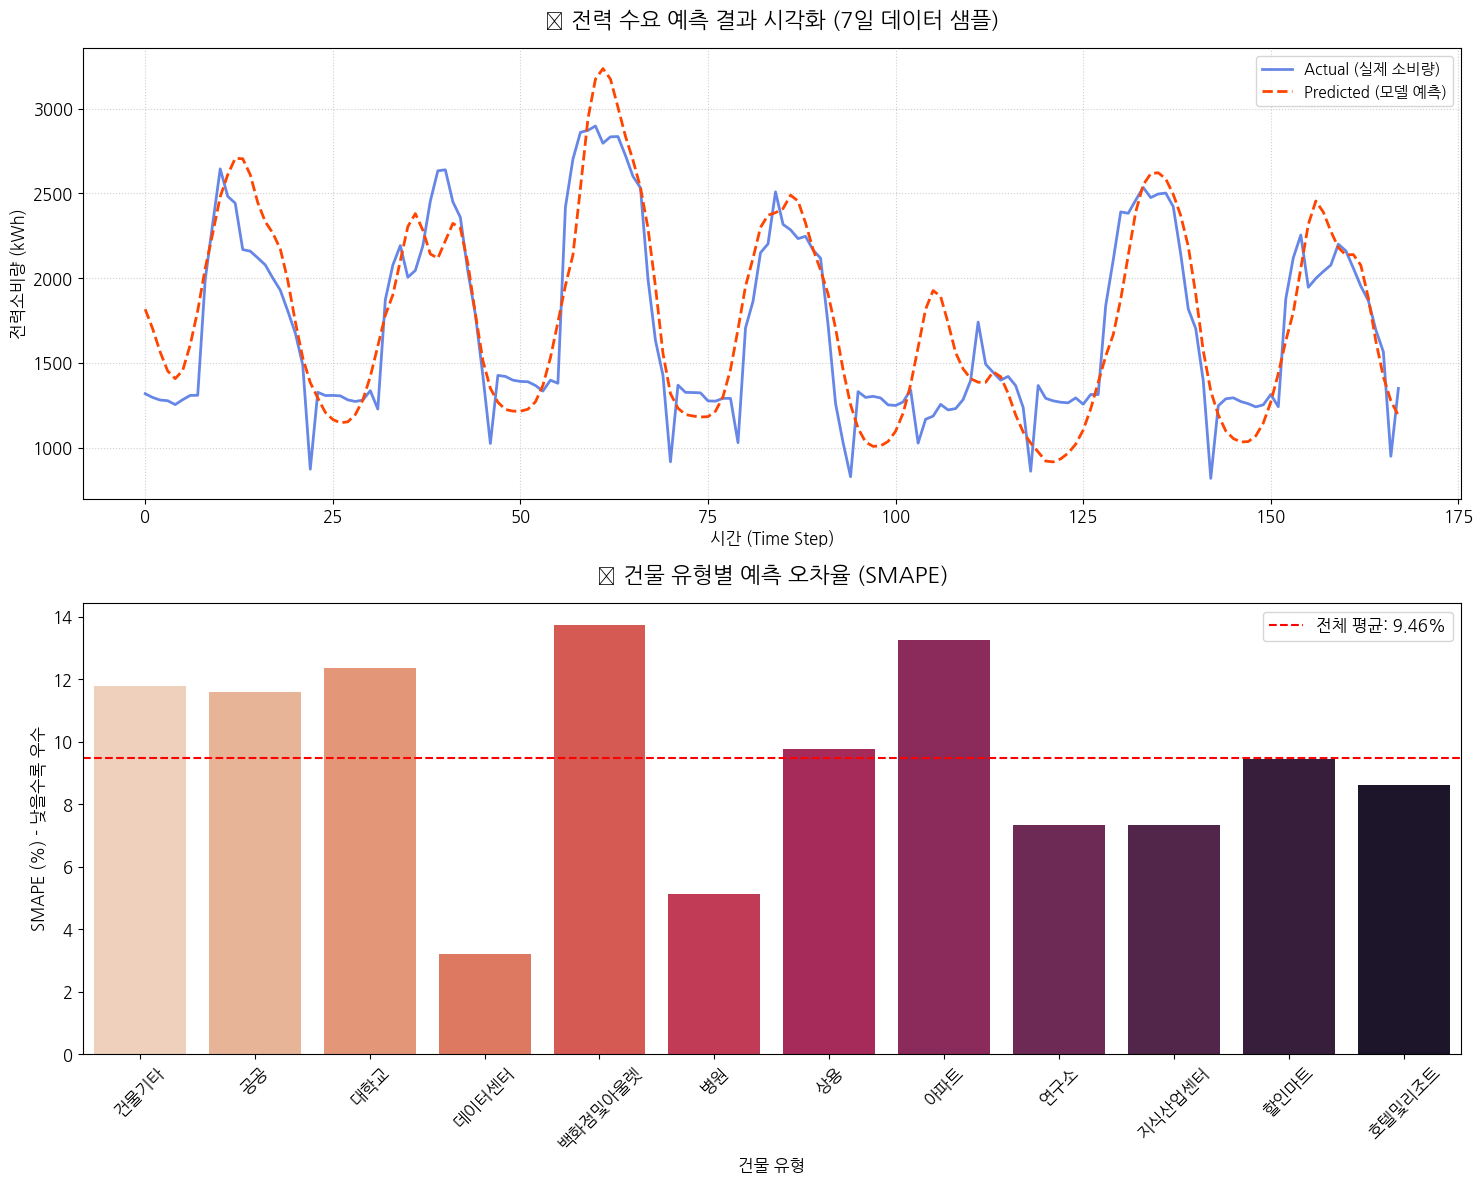


✅ 전체 통합 모델 R2 Score : 0.9667
✅ 전체 통합 모델 SMAPE    : 9.86%


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. 한글 폰트 설정 (Colab 전용)
def setup_colab_font():
    !sudo apt-get update -qq
    !sudo apt-get install -y fonts-nanum > /dev/null
    import matplotlib.font_manager as fm
    import matplotlib.pyplot as plt
    # 나눔고딕 경로 설정 후 캐시 업데이트
    fe = fm.FontEntry(fname='/usr/share/fonts/truetype/nanum/NanumGothic.ttf', name='NanumGothic')
    fm.fontManager.ttflist.insert(0, fe)
    plt.rcParams.update({'font.size': 12, 'font.family': 'NanumGothic', 'axes.unicode_minus': False})

setup_colab_font()

# 2. 결과 시각화 (2개의 서브플롯)
fig, axes = plt.subplots(2, 1, figsize=(15, 12))

# --- [첫 번째 그래프] 실제값 vs 예측값 추이 (7일간 샘플) ---
# total_real, total_pred 변수를 사용합니다.
axes[0].plot(total_real[:168], label='Actual (실제 소비량)', color='royalblue', linewidth=2, alpha=0.8)
axes[0].plot(total_pred[:168], label='Predicted (모델 예측)', color='orangered', linestyle='--', linewidth=2)

axes[0].set_title('⚡ 전력 수요 예측 결과 시각화 (7일 데이터 샘플)', fontsize=16, pad=15)
axes[0].set_xlabel('시간 (Time Step)', fontsize=12)
axes[0].set_ylabel('전력소비량 (kWh)', fontsize=12)
axes[0].legend(loc='upper right', fontsize=11)
axes[0].grid(True, linestyle=':', alpha=0.6)

# --- [두 번째 그래프] 건물 유형별 모델 성능 비교 (R2 & SMAPE) ---
# report_df (유형, R2, SMAPE 포함) 변수를 사용합니다.
# SMAPE는 낮을수록 좋으므로 색상 팔레트를 반전(rocket_r)하여 시각적 직관성을 높였습니다.
report_df = pd.DataFrame(final_report)

sns.barplot(data=report_df, x='유형', y='SMAPE', palette='rocket_r', ax=axes[1])
axes[1].set_title('📉 건물 유형별 예측 오차율 (SMAPE)', fontsize=16, pad=15)
axes[1].set_ylabel('SMAPE (%) - 낮을수록 우수', fontsize=12)
axes[1].set_xlabel('건물 유형', fontsize=12)

# 전체 평균 SMAPE 선 표시 (앙상블 성능 강조용)
avg_smape = report_df['SMAPE'].mean()
axes[1].axhline(avg_smape, color='red', linestyle='--', linewidth=1.5, label=f'전체 평균: {avg_smape:.2f}%')
axes[1].legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3. 수치 요약 출력
print("\n" + "="*50)
print(f"✅ 전체 통합 모델 R2 Score : {total_r2:.4f}")
print(f"✅ 전체 통합 모델 SMAPE    : {total_smape:.2f}%")
print("="*50)